In [ ]:
# Slide 4
# Image Data
# https://www.imageprocessingplace.com/DIP-3E/dip3e_book_images_downloads.htm

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Suppress OpenCV Warnings
os.environ["OPENCV_LOG_LEVEL"] = "ERROR"

def plot_grid(images, titles, rows=1, cols=4, figsize=(16, 4)):
    plt.figure(figsize=figsize)
    for i in range(len(images)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

def dft_transform(img):
    # Convert to float and perform FFT
    f = np.fft.fft2(img)
    # Shift zero frequency component to the center
    fshift = np.fft.fftshift(f)
    return fshift

def idft_transform(fshift):
    # Shift back
    f_ishift = np.fft.ifftshift(fshift)
    # Inverse FFT
    img_back = np.fft.ifft2(f_ishift)
    # Magnitude
    img_back = np.abs(img_back)
    return np.uint8(np.clip(img_back, 0, 255))

4.1 Smoothing Filter (Iterative Application)

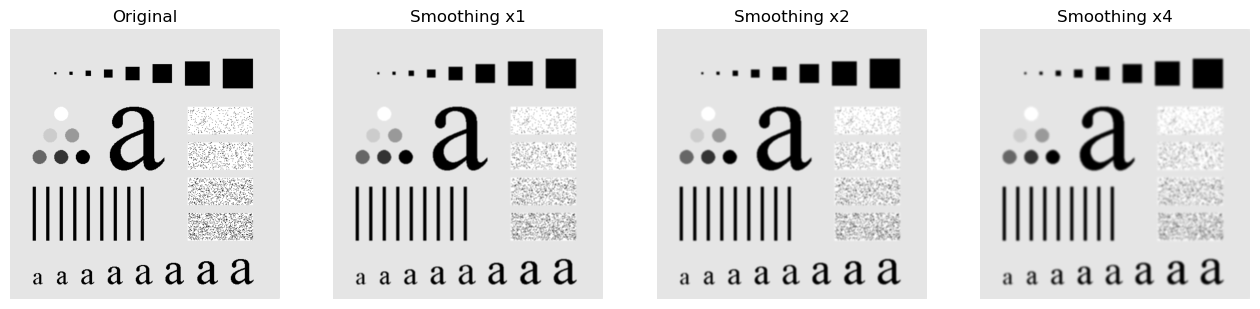

In [ ]:
# 4.1 – Applying a 3x3 Box (Average) filter iteratively (1x, 2x, 4x passes) to observe increased blurring

# Load the image
image_path = 'DIP3E_Original_Images_CH03/Fig0333(a)(test_pattern_blurring_orig).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Create a 3x3 box filter manually
kernel = np.ones((3, 3), np.float32) / 9.0

# Apply filter
pass1 = cv2.filter2D(img, -1, kernel)
pass2 = cv2.filter2D(pass1, -1, kernel) # 2nd pass
pass3 = cv2.filter2D(pass2, -1, kernel) # 3rd pass
pass4 = cv2.filter2D(pass3, -1, kernel) # 4th pass

plot_grid([img, pass1, pass2, pass4],
          ["Original", "Smoothing x1", "Smoothing x2", "Smoothing x4"])

4.2 Weighted Average Filter

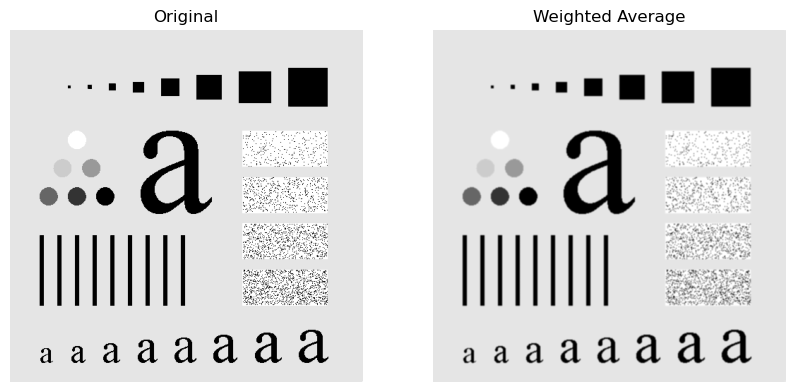

In [ ]:
# 4.2 – Weighted Average Filter gives more importance to the center pixel, preserving edges slightly better

# Load the image
image_path = 'DIP3E_Original_Images_CH03/Fig0333(a)(test_pattern_blurring_orig).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Define Weighted Average Kernel manually
# 1 2 1
# 2 4 2
# 1 2 1
# Sum = 16
kernel_weighted = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16.0

weighted_img = cv2.filter2D(img, -1, kernel_weighted)

plot_grid([img, weighted_img], ["Original", "Weighted Average"], rows=1, cols=2, figsize=(10,5))

4.3 Median Filter (Salt & Pepper Noise)

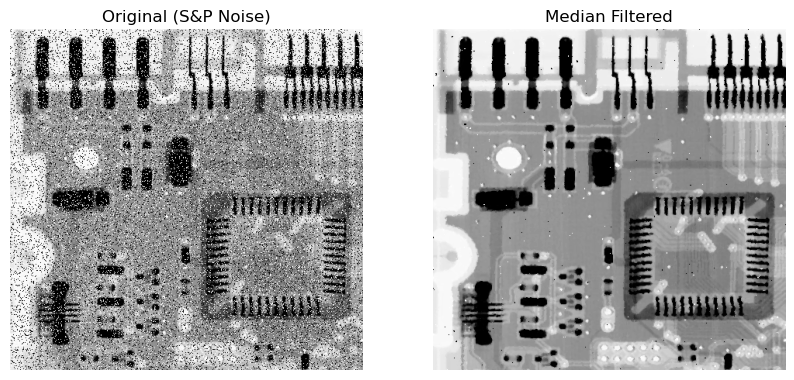

In [ ]:
# 4.3 – Median Filter replaces pixel with median of neighbors, effective for removing Salt & Pepper noise

# Load the image (Noisy Circuit Board)
image_path = 'DIP3E_CH05_Original_Images/Fig0510(a)(ckt-board-saltpep-prob.pt05).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Using cv2.medianBlur which implements the sliding window median sort
# A 3x3 window is standard
median_filtered = cv2.medianBlur(img, 3)

plot_grid([img, median_filtered], ["Original (S&P Noise)", "Median Filtered"], rows=1, cols=2, figsize=(10,5))

4.4 Low Pass Filter (Frequency Domain)

[ WARN:0@0.662] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.662] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.662] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.662] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.662] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.662] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.662] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.662] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

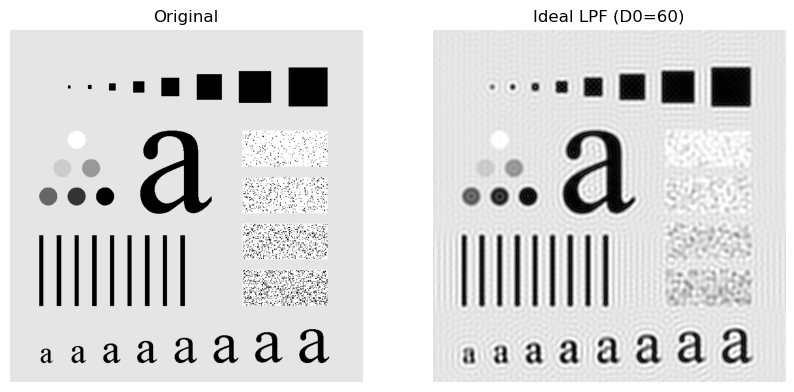

In [ ]:
# 4.4 – Ideal Low Pass Filter (LPF) in Frequency Domain: Attenuates high frequencies (blurring)

# Load the image
image_path = 'DIP3E_Original_Images_CH04/Fig0441(a)(characters_test_pattern).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# 1. Transform to Frequency Domain
fshift = dft_transform(img)
rows, cols = img.shape
crow, ccol = rows//2, cols//2

# 2. Create Ideal LPF Mask (Circle of 1s in center, 0s outside)
D0 = 60 # Cutoff frequency radius
mask = np.zeros((rows, cols), np.uint8)
# Create meshgrid to calculate distance from center
y, x = np.ogrid[:rows, :cols]
dist_from_center = np.sqrt((x - ccol)**2 + (y - crow)**2)
mask[dist_from_center <= D0] = 1

# 3. Apply Mask
fshift_filtered = fshift * mask

# 4. Inverse Transform
img_lpf = idft_transform(fshift_filtered)

plot_grid([img, img_lpf], ["Original", f"Ideal LPF (D0={D0})"], rows=1, cols=2, figsize=(10,5))

4.5 High Pass Filter (Frequency Domain)

[ WARN:0@0.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.826] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

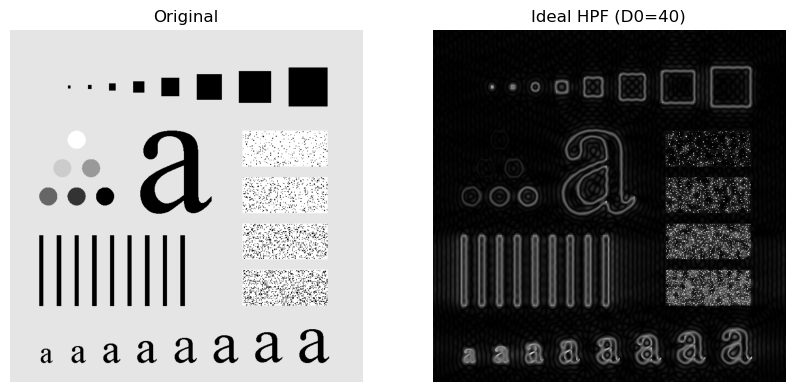

In [ ]:
# 4.5 – Ideal High Pass Filter (HPF): Attenuates low frequencies (edge detection), inverse of LPF

# Load the image
image_path = 'DIP3E_Original_Images_CH04/Fig0441(a)(characters_test_pattern).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# 1. Transform
fshift = dft_transform(img)
rows, cols = img.shape
crow, ccol = rows//2, cols//2

# 2. Create Ideal HPF Mask (1 - LPF)
D0 = 40
# Calculate distance
y, x = np.ogrid[:rows, :cols]
dist_from_center = np.sqrt((x - ccol)**2 + (y - crow)**2)
# Mask is 1 where distance > D0
mask = np.zeros((rows, cols), np.uint8)
mask[dist_from_center > D0] = 1

# 3. Apply Mask
fshift_filtered = fshift * mask

# 4. Inverse Transform
img_hpf = idft_transform(fshift_filtered)

plot_grid([img, img_hpf], ["Original", f"Ideal HPF (D0={D0})"], rows=1, cols=2, figsize=(10,5))

4.6 High Boost Filter

[ WARN:0@0.975] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@0.975] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@0.975] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@0.975] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@0.975] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@0.975] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@0.975] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@0.975] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

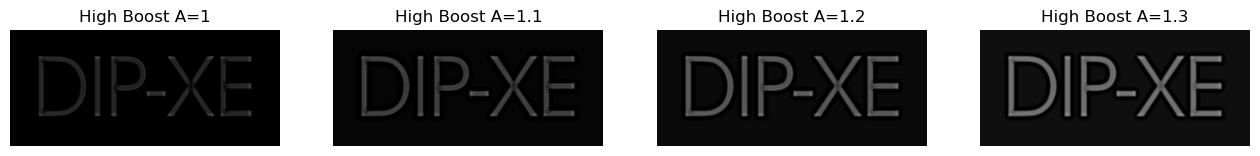

In [ ]:
# 4.6 – High Boost Filter: Adds a weighted portion of the mask (edges) back to the original. Formula: A*Original - LowPass

# Load the image
image_path = 'DIP3E_Original_Images_CH03/Fig0340(a)(dipxe_text).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# 1. Blur the image (Low Pass)
blur = cv2.GaussianBlur(img, (9, 9), 3)

# 2. Calculate Unsharp Mask (Edges) = Original - Blurred
mask = img.astype(float) - blur.astype(float)

# 3. Apply Boost factor A
results = []
A_values = [1, 1.1, 1.2, 1.3]

for A in A_values:
    # Formula: g(x,y) = (A-1)f(x,y) + f_hp(x,y)  OR  g = Original + (A-1)*Original + Mask ... simplifies to Original + k*Mask
    # Standard Def: Highboost = A * Original - Blurred
    # Which is equivalent to: (A-1)*Original + (Original - Blurred) = (A-1)*Original + Mask

    highboost = (A - 1) * img.astype(float) + img.astype(float) + mask # Logic: Original + contribution
    # Simply using the formula: Result = A * Original - Blurred
    highboost = A * img.astype(float) - blur.astype(float)

    highboost = np.clip(highboost, 0, 255).astype(np.uint8)
    results.append(highboost)

plot_grid(results, [f"High Boost A={a}" for a in A_values], rows=1, cols=4)

4.7 Band Pass Filter (Frequency Domain)

[ WARN:0@1.072] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@1.072] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@1.072] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@1.072] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@1.072] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@1.072] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@1.072] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@1.072] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

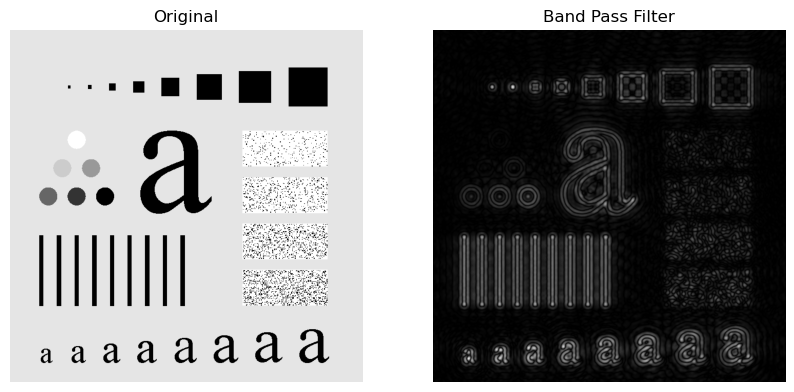

In [ ]:
# 4.7 – Band Pass Filter: Passes frequencies within a specific range (Ring shape mask)

# Load the image
image_path = 'DIP3E_Original_Images_CH04/Fig0441(a)(characters_test_pattern).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

fshift = dft_transform(img)
rows, cols = img.shape
crow, ccol = rows//2, cols//2

# Create Band Pass Mask
D0_inner = 30
D0_outer = 80
y, x = np.ogrid[:rows, :cols]
dist_from_center = np.sqrt((x - ccol)**2 + (y - crow)**2)

# Mask is 1 between Inner and Outer radius
mask = np.zeros((rows, cols), np.uint8)
mask[(dist_from_center >= D0_inner) & (dist_from_center <= D0_outer)] = 1

img_bpf = idft_transform(fshift * mask)

plot_grid([img, img_bpf], ["Original", "Band Pass Filter"], rows=1, cols=2, figsize=(10,5))

4.8 Band Stop Filter (Frequency Domain)

[ WARN:0@1.221] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@1.221] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@1.221] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@1.221] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@1.221] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@1.221] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@1.221] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@1.221] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

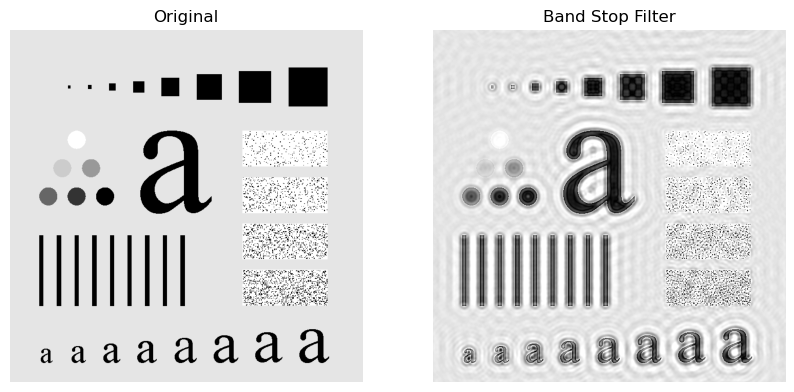

In [ ]:
# 4.8 – Band Stop Filter (Band Reject): Rejects frequencies in a range (Inverse of Band Pass)

# Load the image
image_path = 'DIP3E_Original_Images_CH04/Fig0441(a)(characters_test_pattern).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

fshift = dft_transform(img)
rows, cols = img.shape
crow, ccol = rows//2, cols//2

D0_inner = 30
D0_outer = 80
y, x = np.ogrid[:rows, :cols]
dist_from_center = np.sqrt((x - ccol)**2 + (y - crow)**2)

# Mask is 0 inside the band, 1 everywhere else
mask = np.ones((rows, cols), np.uint8)
mask[(dist_from_center >= D0_inner) & (dist_from_center <= D0_outer)] = 0

img_bsp = idft_transform(fshift * mask)

plot_grid([img, img_bsp], ["Original", "Band Stop Filter"], rows=1, cols=2, figsize=(10,5))

4.9 Padding Conditions

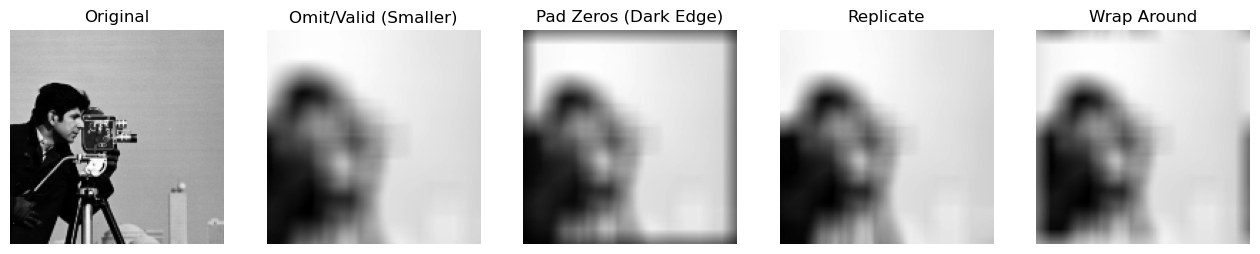

In [ ]:
# 4.9 – Demonstrating padding types: Omit (Valid), Pad 0 (Constant), Replicate, Wrap (Circular)
# Using a large averaging kernel to make padding effects visible on borders

# Load image and crop to see details
image_path = 'DIP3E_Original_Images_CH02/Fig0222(b)(cameraman).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
img_small = img[0:150, 80:230] # Crop header

k_size = 21 # Large kernel to exaggerate border effects
kernel = np.ones((k_size, k_size), np.float32) / (k_size**2)

# 1. Omit Missing (Valid Padding) - Output is smaller
res_valid = cv2.filter2D(img_small, -1, kernel, borderType=cv2.BORDER_CONSTANT)
# Note: cv2.filter2D keeps size by default using default padding. To simulate 'valid', we crop result.
border = k_size // 2
res_valid_crop = res_valid[border:-border, border:-border] # Simulated "No Padding/Valid"

# 2. Pad with 0 (Constant) - Black borders
res_zero = cv2.filter2D(img_small, -1, kernel, borderType=cv2.BORDER_CONSTANT)

# 3. Replicate Border - Smears edge pixels
res_repl = cv2.filter2D(img_small, -1, kernel, borderType=cv2.BORDER_REPLICATE)

# 4. Wrap Around - Circular (Left side wraps to Right)
res_wrap = cv2.filter2D(img_small, -1, kernel, borderType=cv2.BORDER_WRAP)

# Display
plt.figure(figsize=(16, 4))
plt.subplot(1, 5, 1); plt.imshow(img_small, cmap='gray'); plt.title("Original"); plt.axis('off')
plt.subplot(1, 5, 2); plt.imshow(res_valid_crop, cmap='gray'); plt.title("Omit/Valid (Smaller)"); plt.axis('off')
plt.subplot(1, 5, 3); plt.imshow(res_zero, cmap='gray'); plt.title("Pad Zeros (Dark Edge)"); plt.axis('off')
plt.subplot(1, 5, 4); plt.imshow(res_repl, cmap='gray'); plt.title("Replicate"); plt.axis('off')
plt.subplot(1, 5, 5); plt.imshow(res_wrap, cmap='gray'); plt.title("Wrap Around"); plt.axis('off')
plt.show()